In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from natsort import natsorted
from alntk.alignment import Alignment, find_sequence, write_to_fasta
from alntk.sector import highlight_sector
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

In [2]:
num = np.loadtxt("../data/iter_aln_v2_numbering.txt", dtype=str)
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)

In [3]:
red_sector

array([243, 201, 241, 228, 229, 204, 192, 189, 193, 165,   2, 242, 233,
       235, 198, 197, 177])

In [4]:
red_sector_sorted = red_sector.copy()
red_sector_sorted.sort()

In [5]:
num[red_sector]

array(['228', '189', '226', '215', '216', '192', '183', '180', '184',
       '160', '18', '227', '219', '221', '188a', '188', '172'],
      dtype='<U4')

In [6]:
np.array(natsorted(num[red_sector]))

array(['18', '160', '172', '180', '183', '184', '188', '188a', '189',
       '192', '215', '216', '219', '221', '226', '227', '228'],
      dtype='<U4')

In [7]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [8]:
seqs = aln.get_seqs()
descs = aln.get_descs()

In [9]:
with open("../data/iter_aln_v2_redsector.faa", "w") as f:
    for d, s in zip(descs, seqs[:, red_sector_sorted]):
        f.write(">"+d)
        f.write("\n")
        f.write("".join(s))
        f.write("\n")

In [10]:
seqs_red = seqs[:, red_sector_sorted]

In [30]:
def find_representative(aln, identity_threshold, show_steps=False, seed=42):
    # choose the threshold of identity below which removing sequences
    # identity_threshold = 5
    
    # our red sector alignment is L=17 long and has N=89439 sequences
    N, L = aln.shape
    
    # seed the random generator
    np.random.seed(seed)
    
    # initialize the "remaining" set with all the sequences
    remaining = set(range(N))
    
    # initialize the empty list of sequences that are "representatives"
    representatives = []
    
    # while the set of remaining sequences is not depleted
    step = 0
    while remaining:
        step += 1
        # choose a random member of the remaining set
        curr_idx = np.random.choice(list(remaining))
        curr_seq = aln[curr_idx]
    
        # look for the residues that are equal to the current sequence
        # and sum over the resulting array, to compute the identity
        identity_values = np.sum(curr_seq == aln, axis=1)
        # remove the sequences that are closer than the threshold to the current sequence
        too_similar = set(np.where(identity_values >= identity_threshold)[0])
        to_remove = too_similar & remaining
    
        if len(to_remove) == 0:
            # This should only happen if remaining is empty, otherwise something is wrong
            print("WARNING: no sequences removed but remaining is non-empty!")
            break
    
        if (step % 100 == 0) & (show_steps):
            print("step:", step)
            print("remaining:", len(remaining))
            
        remaining -= to_remove
        representatives.append(curr_idx)
    
    print("Found set of representative sequences! Size is", len(representatives))
    return representatives

In [34]:
rep_sizes = []
for i in range(14):
    representatives = find_representative(seqs_red, identity_threshold=i)
    rep_sizes.append(len(representatives))

Found set of representative sequences! Size is 1
Found set of representative sequences! Size is 3
Found set of representative sequences! Size is 6
Found set of representative sequences! Size is 21
Found set of representative sequences! Size is 53
Found set of representative sequences! Size is 159
Found set of representative sequences! Size is 400
Found set of representative sequences! Size is 899
Found set of representative sequences! Size is 1754
Found set of representative sequences! Size is 3024
Found set of representative sequences! Size is 4786
Found set of representative sequences! Size is 7045
Found set of representative sequences! Size is 9755
Found set of representative sequences! Size is 13086


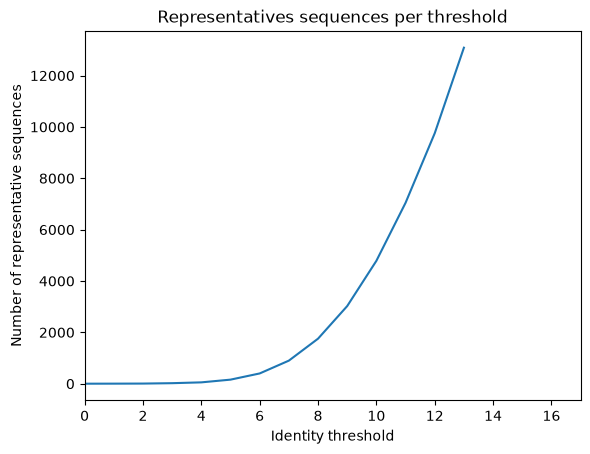

In [36]:
plt.figure()
plt.title("Representatives sequences per threshold")
plt.plot(rep_sizes)
plt.xlabel("Identity threshold")
plt.ylabel("Number of representative sequences")
plt.xlim([0, 17])
plt.show()

In [177]:
representatives = find_representative(seqs_red, identity_threshold=7, seed=3)
seqs_red_rep = seqs_red[representatives]

Found set of representative sequences! Size is 882


## PCA of red sector

In [178]:
ch_accs = ["P07338", "P17538", "P80646", "P00767", "Q7M3E1", "Q61759", "Q6GPI", "P04813", "P00766"]
tr_accs = ["P00760", "P07477", "P00762", "P07478", "P35030", "Q9R0T7", "P07146", "P00763", "P35031", "P35033"]
el_accs = ["P08217", "P08218", "P08419", "Q7SIG3", "P05208", "P00773", "Q91X79", "P00772", "Q29461", "P09093", "Q28153", "P00774"]

In [179]:
ch_idxs, tr_idxs, el_idxs = [], [], []

for desc_idx, desc in enumerate(descs):
    for accession in desc.split("_"):
        if accession in ch_accs:
            ch_idxs.append(desc_idx)
        elif accession in tr_accs:
            tr_idxs.append(desc_idx)
        elif accession in el_accs:
            el_idxs.append(desc_idx)

Found set of representative sequences! Size is 889


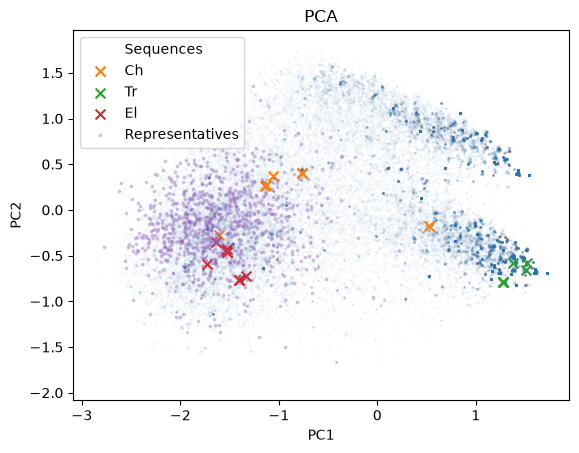

Found set of representative sequences! Size is 882


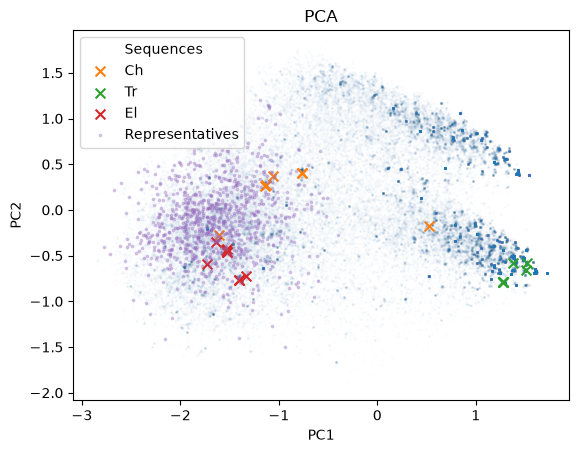

Found set of representative sequences! Size is 889


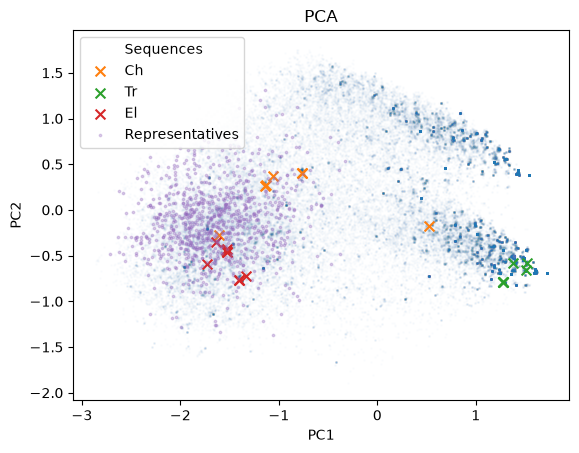

Found set of representative sequences! Size is 899


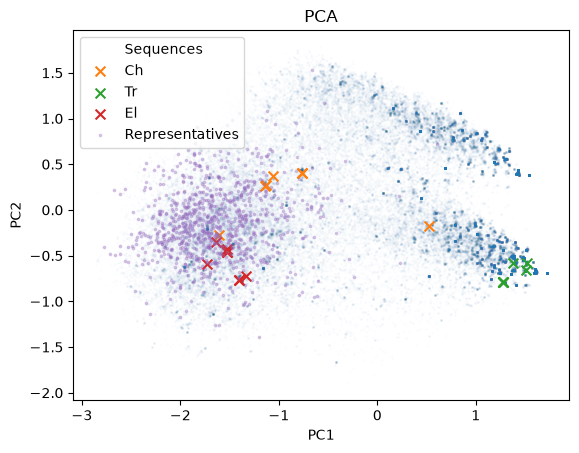

Found set of representative sequences! Size is 900


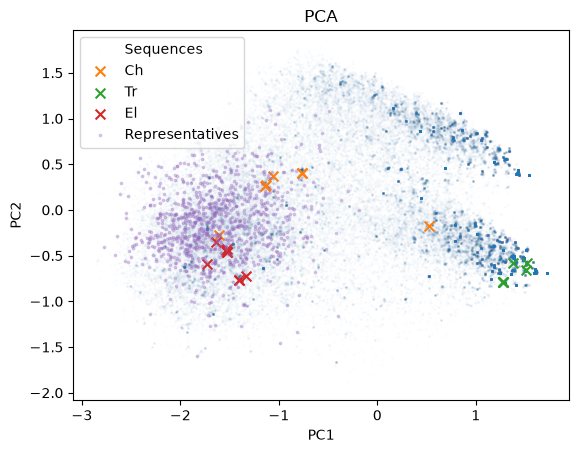

Found set of representative sequences! Size is 886


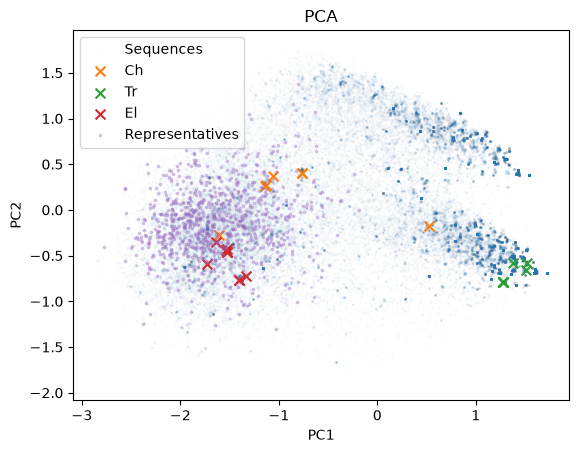

In [183]:
reference_seqs = seqs_red.copy()

pc_a, pc_b = 0, 1

for seed in [0, 3, 236, 42, 103, 47]:
    representatives = find_representative(seqs_red, identity_threshold=7, seed=seed)
    seqs_red_rep = seqs_red[representatives]
    
    ohe = OneHotEncoder(handle_unknown='ignore')
    reference_seqs_ohe = ohe.fit_transform(reference_seqs)
    
    pca = PCA(n_components=3, svd_solver='arpack')
    pca.fit(reference_seqs_ohe)
    reference_pca = pca.transform(reference_seqs_ohe)
    
    fig, ax = plt.subplots()
    ax.set_title("PCA")
    ax.scatter(reference_pca[:, pc_a], reference_pca[:, pc_b], s=1, alpha=.01, label="Sequences")
    ax.scatter(reference_pca[ch_idxs, pc_a], reference_pca[ch_idxs, pc_b], s=50, alpha=1, label="Ch", marker="x")
    ax.scatter(reference_pca[tr_idxs, pc_a], reference_pca[tr_idxs, pc_b], s=50, alpha=1, label="Tr", marker="x")
    ax.scatter(reference_pca[el_idxs, pc_a], reference_pca[el_idxs, pc_b], s=50, alpha=1, label="El", marker="x")
    ax.scatter(reference_pca[representatives, pc_a], reference_pca[representatives, pc_b], s=3, alpha=.3, color="tab:purple", label="Representatives")
    ax.set_xlabel(f'PC{pc_a+1}')
    ax.set_ylabel(f'PC{pc_b+1}')
    plt.legend()
    plt.show()

In [15]:
import numpy as np

# Expand dimensions to compare all pairs:
# seqs_red[None, :, :] -> (1, N, L)
# seqs_red[:, None, :] -> (N, 1, L)
# mismatches[i, j, k] = (seqs_red[i, k] != seqs_red[j, k])
mismatches = (seqs_red_rep[None, :, :] != seqs_red_rep[:, None, :])  # shape (N, N, L)

# Hamming distance = number of mismatches along the sequence axis
hamming_dist = mismatches.sum(axis=2)  # shape (N, N)

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [22]:
dist_condensed = squareform(hamming_dist, checks=False)
Z = linkage(dist_condensed, method="ward")

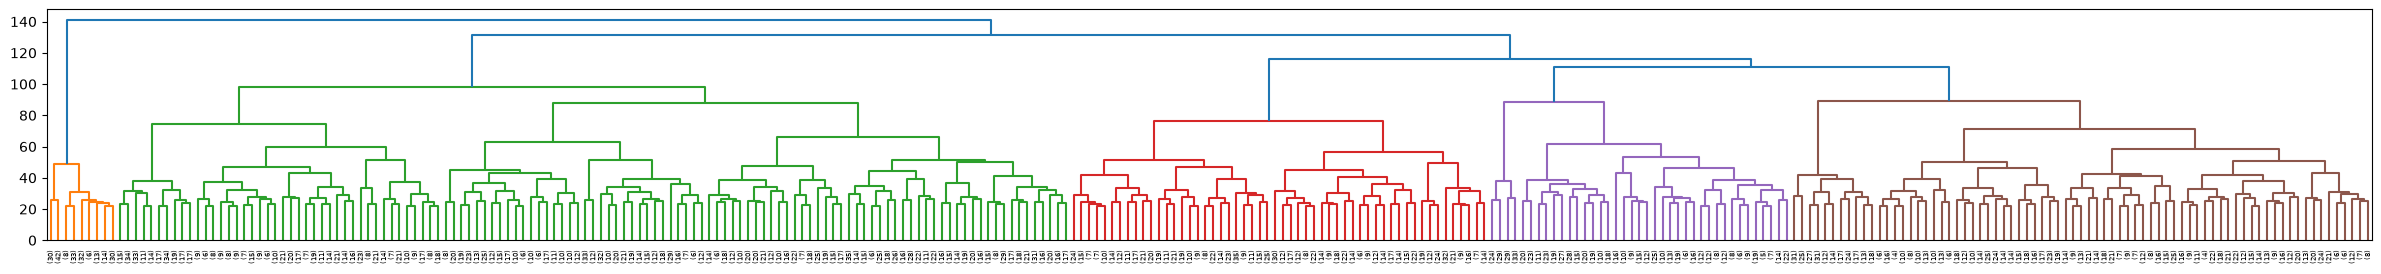

In [29]:
plt.figure(figsize=(30,3))
dendrogram(Z, truncate_mode="lastp", p=300)
plt.show()

# Sandbox